# WD Classification primer

In the following notebook we'll take a look at processing the label information from the spectroscopic classification campaign of SDSS, of around 23000 v6_0_2 BOSS spectra obtained for the mwm_wd and mwm_cb cartons. 

We'll also do data processing of the associated .dat files for our labeled observations, building a data processing pipeline for machine learning model training.

We will save our processed data into numpy arrays. This will include six numpy arrays corresponding to spectrum data and label data of the validation, test and training sets.

## Loading Label information

First, we must download the label informartion which is hosted on a google drive folder, and consists of several .csv files. We've saved the files on a local folder which is represented in the variable "path" of the next cell. Some excel duplicates where found and manually removed from the folder. Now, we can gather the desired "fields" or columns from all this files and merge them into a pandas dataframe.

In [3]:
from pathlib import Path
import os

# Set current directory for using relative paths

current_dir =  Path(globals()['_dh'][0])
project_dir =  Path(globals()['_dh'][0]).parent

try:
    os.mkdir(os.path.join(current_dir, '1.0-jrb-alternative-approach'))
except:
    print("Failed to create folder. Perhaps the folder already exists, or there's a permissions issue.")

Failed to create folder. Perhaps the folder already exists, or there's a permissions issue.


In [4]:
import pandas as pd

path = os.path.join(project_dir, r'data\raw\label_data')
fields = ['File Name', 'MJD', 'Target ID', 'DB ID' ,'Classification', 'Data Quality']

raw_labels_df = pd.DataFrame()

# We import all of the csv files and merge them in star_df

for filename in os.listdir(path):
    file_path = os.path.join(path, filename)
    df = pd.read_csv (file_path, usecols=fields)
    raw_labels_df = pd.concat([raw_labels_df, df], ignore_index=True)
print(raw_labels_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35253 entries, 0 to 35252
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Classification  35253 non-null  object
 1   DB ID           35253 non-null  int64 
 2   Data Quality    11158 non-null  object
 3   File Name       35253 non-null  object
 4   MJD             35253 non-null  int64 
 5   Target ID       35253 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 1.6+ MB
None


In [5]:
raw_labels_df

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
0,WDA,21899,NaN,spec-15249-59265-04601916346-21899.png,59265,4601916346
1,sdX,23360,BLEND,spec-15301-59338-04602344336-23360.png,59338,4602344336
2,WDA,18900,SNR,spec-15113-59217-04538755416-18900.png,59217,4538755416
3,WDA,18575,NaN,spec-15086-59267-04474143209-18575.png,59267,4474143209
4,WD,20528,SNR,spec-15198-59269-04351438385-20528.png,59269,4351438385
...,...,...,...,...,...,...
35248,WDA,15895,SNR,spec-15011-59222-04399876473-15895.png,59222,4399876473
35249,WDA,20605,NaN,spec-15200-59324-04589320996-20605.png,59324,4589320996
35250,WDA,19388,NaN,spec-15193-59243-04594923329-19388.png,59243,4594923329
35251,DUNNO,19161,SNR,spec-15121-59212-04342114705-19161.png,59212,4342114705


We can see there is some NaN values in the Data Quality column from when no data quality comment was offered. For now, let's assume this data can be considererd OK, which is reasonable. 

Let's take a look at the label distribution.

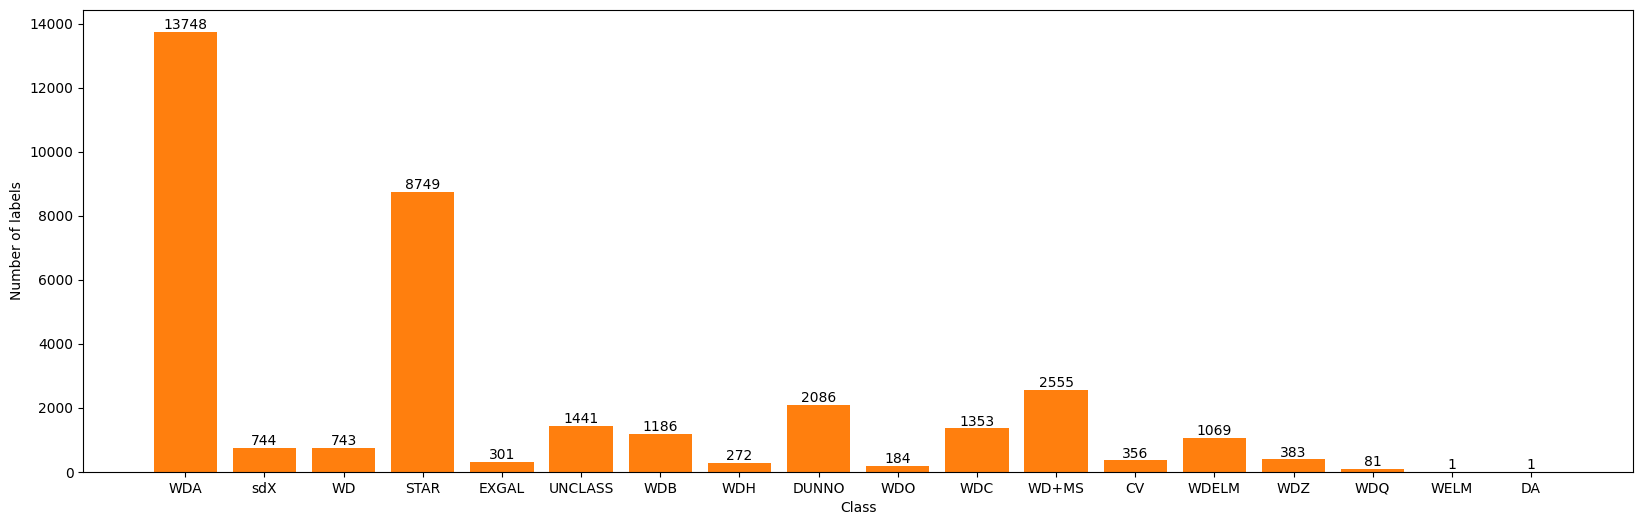

In [6]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# Plot bar graph of labels

counter = Counter(raw_labels_df['Classification'])
star_class = counter.keys()
star_counts = counter.values()
indexes = np.arange(len(star_class))
width = 0.7

fig, ax = plt.subplots(figsize=(20,6))

ax.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)

plt.xlabel('Class')
plt.ylabel('Number of labels')
plt.xticks(indexes, labels=star_class)
plt.show()

We can see there's probably two mislabeled elements, WELM and DA. We can make the tag corrections now, and we will also change the NaN values in the Data Quality column by an 'OK' string.

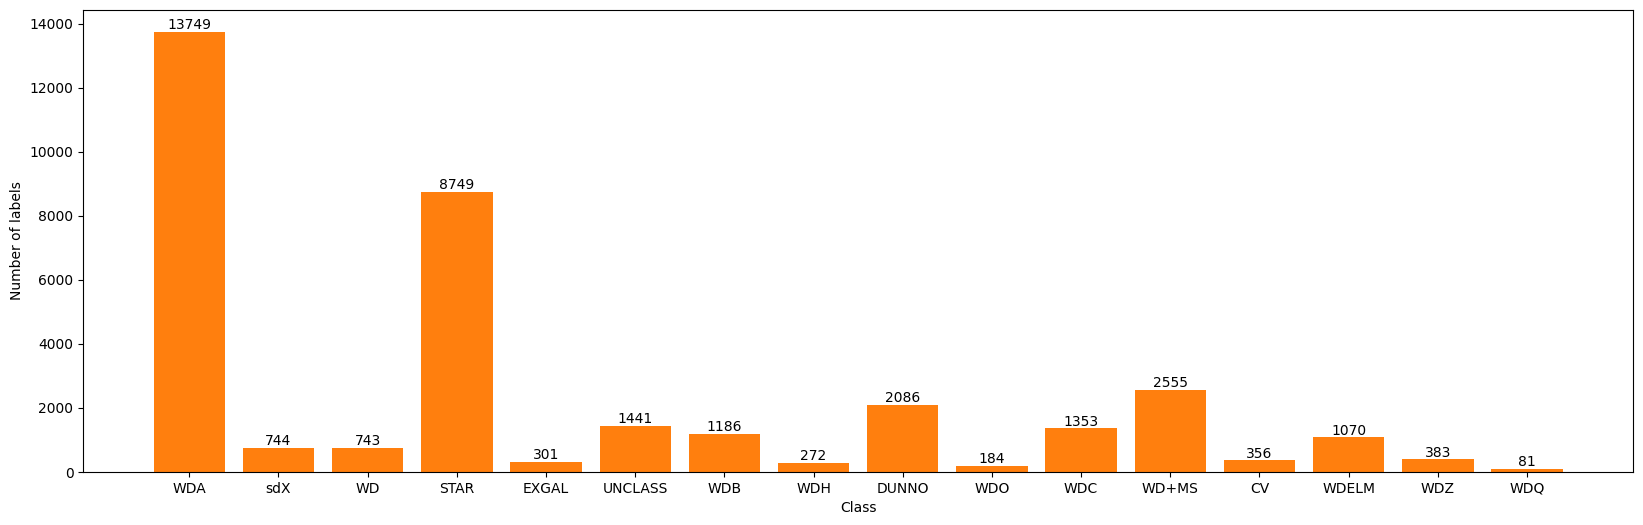

In [7]:
# Mislabeled elements correction

raw_labels_df.loc[raw_labels_df['Classification'] == 'WELM', 'Classification'] = 'WDELM'
raw_labels_df.loc[raw_labels_df['Classification'] == 'DA', 'Classification'] = 'WDA'


# Changing the NaNs data quality abscence of comment with an 'OK'

raw_labels_df['Data Quality'] = raw_labels_df['Data Quality'].fillna('OK')

# Plot bar graph of labels

counter = Counter(raw_labels_df['Classification'])
star_class = counter.keys()
star_counts = counter.values()

indexes = np.arange(len(star_class))
width = 0.7

fig, ax = plt.subplots(figsize=(20,6))

ax.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)

plt.xlabel('Class')
plt.ylabel('Number of labels')
plt.xticks(indexes, labels=star_class)
plt.show()

We can know check the Data quality comments distribution

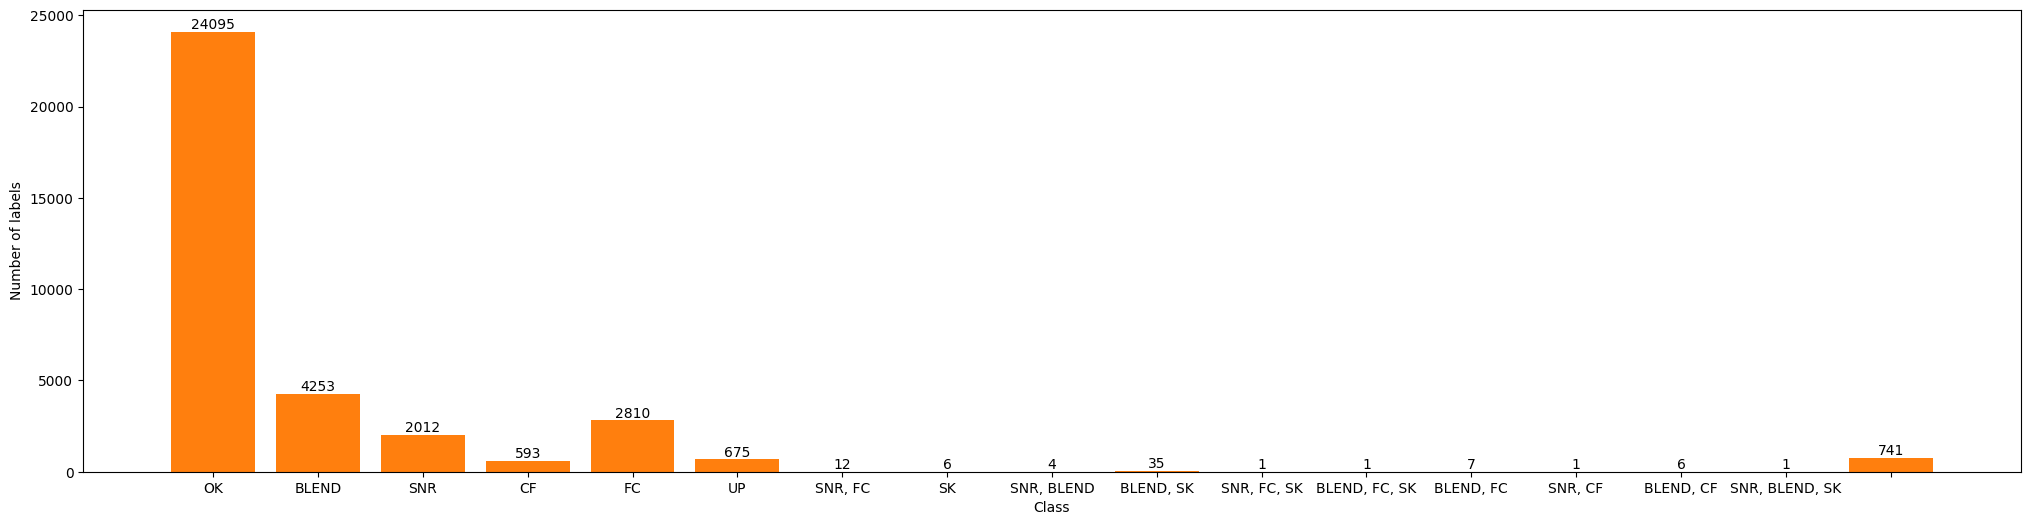

In [8]:
counter = Counter(raw_labels_df['Data Quality'])
star_class = counter.keys()
star_counts = counter.values()

# Plot bar graph of star Data Quality Comments using matplotlib

indexes = np.arange(len(star_class))
width = 0.7

fig, ax = plt.subplots(figsize=(25,6))

ax.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)

plt.xlabel('Class')
plt.ylabel('Number of labels')
plt.xticks(indexes, labels=star_class)
plt.show()

We can see that, on the one side, there's multiple Data Quality Comments for a star minority, and that there is a misterious blank comment (or ' ' string comment), different from the 'OK' string (Previously NaNs). We will asume these tags can be labeled as 'OK' also, as they are classified samples with no (bad) data quality comments. 

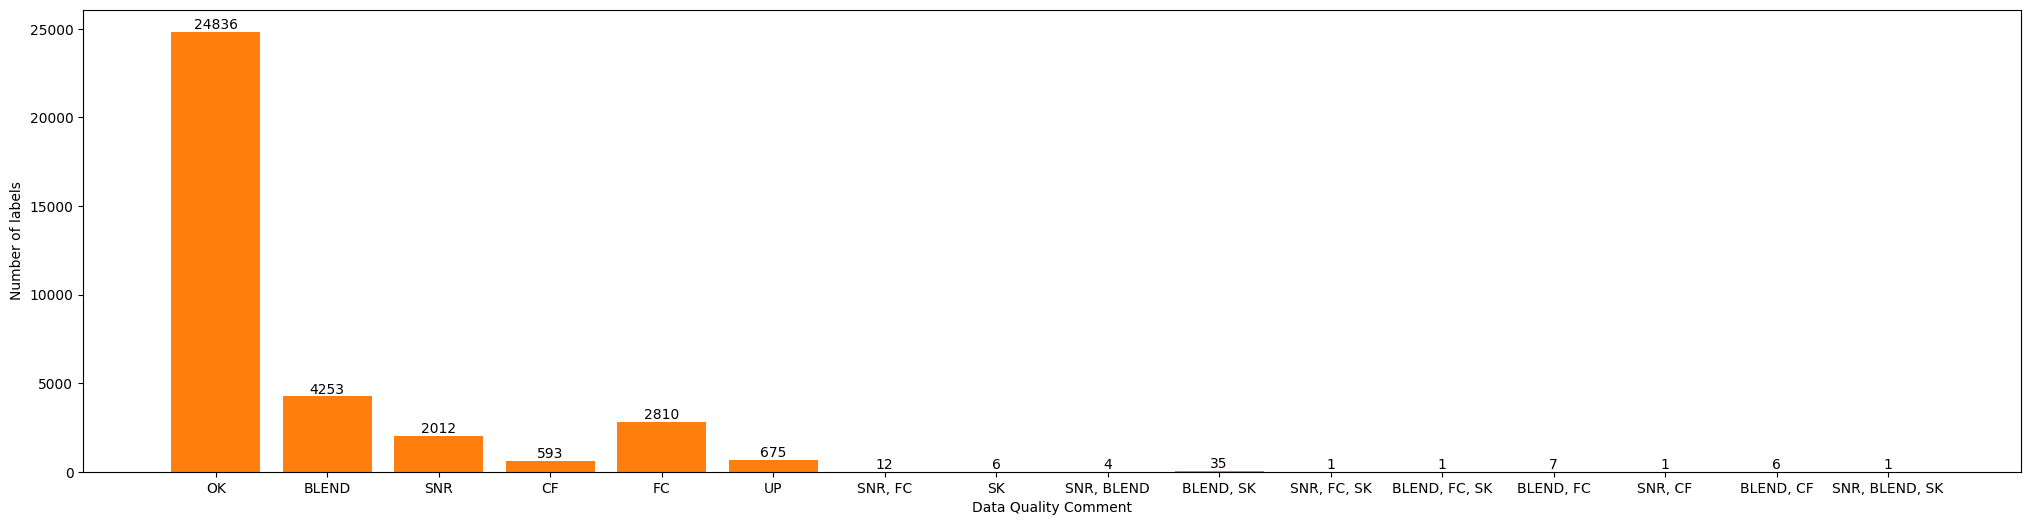

In [9]:
# change empty commentary by OK.

raw_labels_df.loc[raw_labels_df['Data Quality'] == ' ', 'Data Quality'] = 'OK'

counter = Counter(raw_labels_df['Data Quality'])
star_class = counter.keys()
star_counts = counter.values()

# Plot bar graph of star Data Quality Comments using matplotlib

indexes = np.arange(len(star_class))
width = 0.7

fig, ax = plt.subplots(figsize=(25,6))

ax.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)

plt.xlabel('Data Quality Comment')
plt.ylabel('Number of labels')
plt.xticks(indexes, labels=star_class)
plt.show()

This looks better. Next, we'd like to find out how many of the same stellar objects are actually labeled, not counting repetitions for different observations.

In [10]:
target_id = raw_labels_df['Target ID']

# Duplicated values are marked as True, except the first element found, which is kept as False.

target_id.duplicated(keep='first').value_counts()

Target ID
True     25349
False     9904
Name: count, dtype: int64

So, there's actually 9904 unique stellar elements whit multiple observations, and thus, Data Quality Comments and Classifications may vary between each observation. This means we need to define a way to parse this data for the following ML algorithms. Let's explore a particular random element for illustration.

In [11]:
# Get data drom element with target ID 4342114705 

raw_labels_df.loc[raw_labels_df['Target ID'] == 4342114705]

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
4158,STAR,19161,BLEND,spec-15121-59206-04342114705-19161.png,59206,4342114705
25514,STAR,19161,OK,spec-15121-59212-04342114705-19161.png,59212,4342114705
29241,DUNNO,19161,BLEND,spec-15121-59206-04342114705-19161.png,59206,4342114705
33146,STAR,19161,BLEND,spec-15121-59206-04342114705-19161.png,59206,4342114705
35251,DUNNO,19161,SNR,spec-15121-59212-04342114705-19161.png,59212,4342114705


What can we do we the data quality comments? Even if there were no comments, how do we decide the correct label for each element? these are the core issues. Let's define a simple pre-processing policy for the labels.

## Pre-processing Label information

Now we can focuse on an approach to pre-process label information for the upcoming ML algorithms. The approach I take here is to exclude all files with data quality issues first, meaning these will be considered as invalid information and will not be used for the upcoming machine laerning algorithms.

In [12]:
qlabels_df = raw_labels_df.copy()

qlabels_df.drop(qlabels_df[qlabels_df['Data Quality'] != 'OK'].index, inplace = True)

In [13]:
qlabels_df

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
0,WDA,21899,OK,spec-15249-59265-04601916346-21899.png,59265,4601916346
3,WDA,18575,OK,spec-15086-59267-04474143209-18575.png,59267,4474143209
5,WDA,22243,OK,spec-15266-59306-04592699543-22243.png,59306,4592699543
6,WDA,19555,OK,spec-15165-59202-04545012720-19555.png,59202,4545012720
7,WD,20892,OK,spec-15221-59245-04306649216-20892.png,59245,4306649216
...,...,...,...,...,...,...
35242,STAR,20434,OK,spec-15288-59294-04552877469-20434.png,59294,4552877469
35244,STAR,20259,OK,spec-15195-59271-04543081849-20259.png,59271,4543081849
35246,STAR,20046,OK,spec-15285-59304-04550841319-20046.png,59304,4550841319
35249,WDA,20605,OK,spec-15200-59324-04589320996-20605.png,59324,4589320996


In [14]:
# Let's explore how many unique stellar objects we have left.

qlabels_df['Target ID'].duplicated(keep='first').value_counts()

Target ID
True     16723
False     8113
Name: count, dtype: int64

In [15]:
# Let's look at element 4553795050 as an example.

qlabels_df.loc[qlabels_df['Target ID'] == 4553795050]

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
4234,WDB,19293,OK,spec-15127-59190-04553795050-19293.png,59190,4553795050
12013,WDC,19293,OK,spec-15190-59248-04553795050-19293.png,59248,4553795050
17274,WDA,19293,OK,spec-15190-59273-04553795050-19293.png,59273,4553795050
18200,WDB,19293,OK,spec-15127-59219-04553795050-19293.png,59219,4553795050
19215,WDC,19293,OK,spec-15190-59248-04553795050-19293.png,59248,4553795050
28327,WDB,19293,OK,spec-15127-59219-04553795050-19293.png,59219,4553795050
33724,WDC,19293,OK,spec-15190-59273-04553795050-19293.png,59273,4553795050
34566,WDB,19293,OK,spec-15190-59267-04553795050-19293.png,59267,4553795050
34673,WDB,19293,OK,spec-15127-59190-04553795050-19293.png,59190,4553795050
35240,WDC,19293,OK,spec-15190-59248-04553795050-19293.png,59248,4553795050


Now, we can focus on how to resolve the fact that a same object can have several different classification labels from different evaluations, and each may be from a different observation (as reflected by the Modified Julian Date number, or MJD, for example), but not necesarilly (there can be discenting labels for exactly the same data, probably made by different labelers). One option could be to consider the official classification Label as the most voted one, resolving ties to either way.

In [16]:
# The following statement will return most applied label for each element, given the target ID field, as a one dimensional list.

qlabels_df.loc[qlabels_df['Target ID'] == 4553795050]['Classification'].mode().to_list()

['WDB']

For simplicity, in this first run, I have decided to use ONLY ONE of the data files associated to each unique Target ID, and it has to come from a file that produced a label matching the "most voted" one by the evaluators. This means we will use only one .dat file per object when training the ML classifier.

In [17]:
# the following routine calculates, per object id, the mode of the class labels, or the "most voted" label by the evaluators. It then keeps the information from ONE of the observations, with the same label as the mode. 

star_df = pd.DataFrame()

for object_id in qlabels_df['Target ID'].unique():
    mode_per_object = qlabels_df.loc[qlabels_df['Target ID'] == object_id]['Classification'].mode().to_list()[0]
    selected_row = qlabels_df.loc[(qlabels_df['Classification'] == mode_per_object) & (qlabels_df['Target ID'] == object_id)].iloc[0]
    star_df = pd.concat([star_df, pd.DataFrame(selected_row).transpose()])

We notice the int64 columns where changed to floats during the process, let's convert them back

In [18]:
star_df = star_df.astype({"DB ID": 'int64', "MJD": 'int64', "Target ID" : 'int64'})
star_df

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
0,WDA,21899,OK,spec-15249-59265-04601916346-21899.png,59265,4601916346
3,WDA,18575,OK,spec-15086-59267-04474143209-18575.png,59267,4474143209
5,WDA,22243,OK,spec-15266-59306-04592699543-22243.png,59306,4592699543
6,WDA,19555,OK,spec-15165-59202-04545012720-19555.png,59202,4545012720
7,WD,20892,OK,spec-15221-59245-04306649216-20892.png,59245,4306649216
...,...,...,...,...,...,...
35209,WD+MS,25029,OK,spec-15346-59300-05208867797-25029.png,59300,5208867797
35211,WDC,17158,OK,spec-15034-59165-04382235429-17158.png,59165,4382235429
35225,STAR,20417,OK,spec-15288-59294-04552859261-20417.png,59294,4552859261
35226,STAR,25989,OK,spec-15370-59338-04347784790-25989.png,59338,4347784790


In [19]:
star_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8113 entries, 0 to 35229
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Classification  8113 non-null   object
 1   DB ID           8113 non-null   int64 
 2   Data Quality    8113 non-null   object
 3   File Name       8113 non-null   object
 4   MJD             8113 non-null   int64 
 5   Target ID       8113 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 443.7+ KB


We can now get a view of how many classes we have left for actual training.

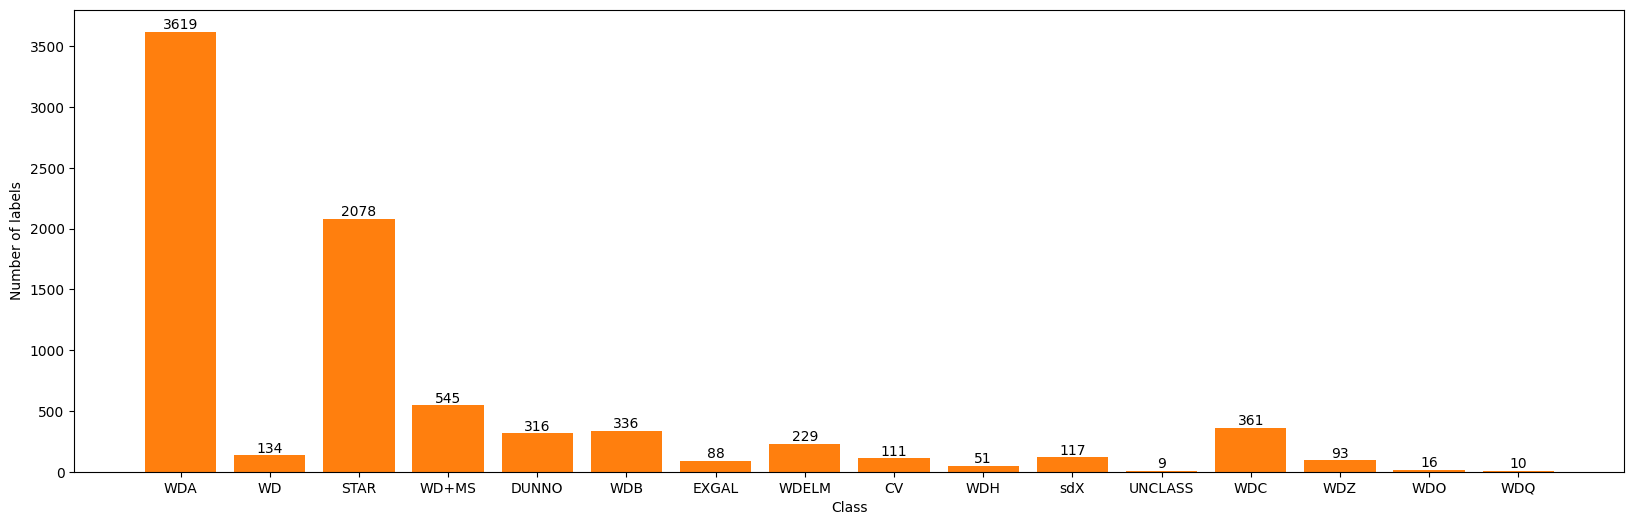

In [20]:
# Plot bar graph of labels

counter = Counter(star_df['Classification'])
star_class = counter.keys()
star_counts = counter.values()
indexes = np.arange(len(star_class))
width = 0.7

fig, ax = plt.subplots(figsize=(20,6))

ax.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)

plt.xlabel('Class')
plt.ylabel('Number of labels')
plt.xticks(indexes, labels=star_class)
plt.show()

Before we proceed, we will drop de DUNNO, STAR, EXGAL and UNCLASS classes, as it's unlikely they have a coherent sprectrum along the samples, and they are of no interest to us, as we wish to classify WD sub types.

In [21]:
star_df.drop(star_df.index[star_df['Classification'] == 'DUNNO'], inplace = True)
star_df.drop(star_df.index[star_df['Classification'] == 'UNCLASS'], inplace = True)
star_df.drop(star_df.index[star_df['Classification'] == 'STAR'], inplace = True)
star_df.drop(star_df.index[star_df['Classification'] == 'EXGAL'], inplace = True)

## Creating dataframe with file paths and class 

We will be working with the .dat files downloaded from SDSS5, rather than directly with the .fits files. For this simple example, we have downloaded app 41GB of data from SDSS in the from of dat files. The folders are arranged as follows:

In [22]:
# We have downloaded the SDSS5 data to the following folder.

sdss_data_path = os.path.join(project_dir, r'data\raw\sdss_dat_files')

# List of folders downloaded from SDSS.

print(os.listdir(sdss_data_path))

['100pc', '250pc', 'cb_300pc', 'cb_cvcandidates', 'cb_gaiagalex', 'cb_uvex1', 'cb_uvex2', 'cb_uvex3', 'cb_uvex4', 'cb_uvex5', 'wd']


In [23]:
# Let's use again, element 4553795050 as an example and see which .dat files associated to this object can we find.

Target_id = '4553795050'
folder_list = os.listdir(sdss_data_path)
for folder in folder_list:
    dat_files_path = os.path.join(sdss_data_path, folder)
    for filename in os.listdir(dat_files_path):
        if Target_id in filename and filename.endswith('.dat'):
            print(os.path.join(folder, filename))

cb_gaiagalex\SDSSJ073515.14+362444.7_15127-59190-0428_4553795050.dat
cb_gaiagalex\SDSSJ073515.14+362444.7_15127-59219-0432_4553795050.dat
cb_gaiagalex\SDSSJ073515.14+362444.7_15190-59248-0371_4553795050.dat
cb_gaiagalex\SDSSJ073515.14+362444.7_15190-59267-0183_4553795050.dat
cb_gaiagalex\SDSSJ073515.14+362444.7_15190-59273-0195_4553795050.dat
cb_uvex2\SDSSJ073515.14+362444.7_15127-59190-0428_4553795050.dat
cb_uvex2\SDSSJ073515.14+362444.7_15127-59219-0432_4553795050.dat
cb_uvex2\SDSSJ073515.14+362444.7_15190-59248-0371_4553795050.dat
cb_uvex2\SDSSJ073515.14+362444.7_15190-59267-0183_4553795050.dat
cb_uvex2\SDSSJ073515.14+362444.7_15190-59273-0195_4553795050.dat
wd\SDSSJ073515.14+362444.7_15127-59190-0428_4553795050.dat
wd\SDSSJ073515.14+362444.7_15127-59219-0432_4553795050.dat
wd\SDSSJ073515.14+362444.7_15190-59248-0371_4553795050.dat
wd\SDSSJ073515.14+362444.7_15190-59267-0183_4553795050.dat
wd\SDSSJ073515.14+362444.7_15190-59273-0195_4553795050.dat


We can see theres multiple .dat files, each associted with a different Modified Julian Date (MJD), for the same object, and in different folders. Lets plot one:

C:\Users\javip\AppData\Local\Temp\ipykernel_13888\1408312007.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


Text(0, 0.5, 'Flux')

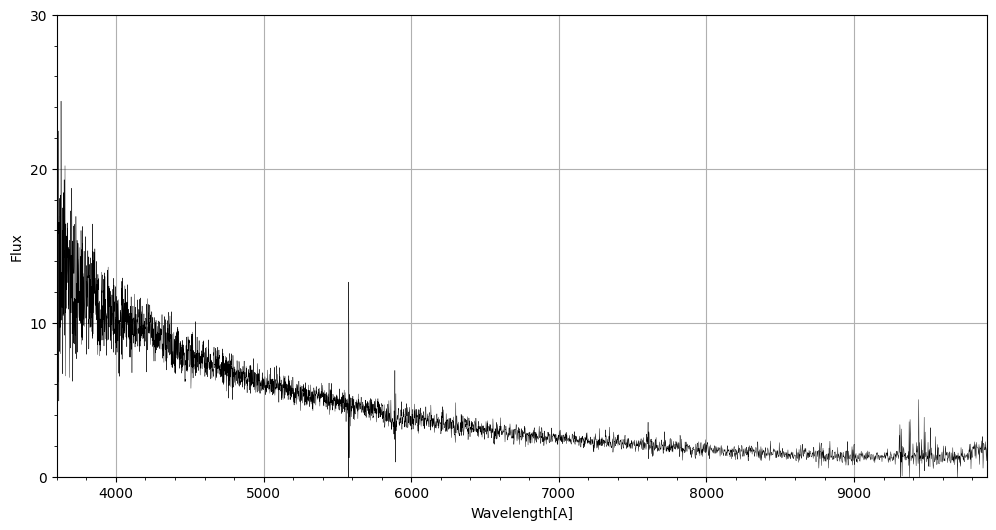

In [24]:
# Unpack SDSSJ073515.14+362444.7_15127-59219-0432_4553795050.dat file and plot:

file_path = os.path.join(sdss_data_path, 'wd\SDSSJ073515.14+362444.7_15127-59219-0432_4553795050.dat')

sed = np.loadtxt(file_path, unpack = True)
wavelength = sed[0,:]
flux = sed[1,:]
ivar = sed[2,:]

fig, ax = plt.subplots(figsize=(12, 6))
ax.grid(True)
ax.legend(frameon=False)
ax.plot(wavelength, (flux * 10 ** 17), linewidth=0.3, color='black')
ax.set_xlim([3600, 9900])
ax.set_ylim([0, 30])
ax.xaxis.set_minor_locator(plt.MultipleLocator(200))
ax.yaxis.set_minor_locator(plt.MultipleLocator(2))
ax.yaxis.set_major_locator(plt.MultipleLocator(10))
plt.xlabel('Wavelength[A]')
plt.ylabel('Flux')


For our problem, the x feature will be the information in each .dat data file, while de Y feature will be the class assgined. Let us first build a dataframe with two columns: the file path for each dat file and the class.

In [25]:
# This routine is way too inefficient, have to optimize it.

# file_list = os.listdir(sdss_data_path)
# spectrum_df1 = pd.DataFrame(columns=['filename', 'classID'])

# for index, row in star_df_final.iterrows():
#     found_flag = 0
#     for filename in file_list:
#         if str(row['Target ID']) in filename and str(row['MJD']) in filename:
#             spectrum_df1 = spectrum_df1.append({'filename' : filename, 'classID' : row['Classification']}, ignore_index=True)
#             found_flag = 1
#             break
#     if found_flag == 0:
#         print('file not found for MJD:{}, TID:{}'.format(row['MJD'], row['Target ID']))

In [26]:
# This routines searches for the file path for each target id and MJD.
# First we process the file names to make a dict and take advantage of its
# hashed structure. Depends on data filename structure but way more efficient.
# Then we use this dictionary to find the right data path.


folder_list = os.listdir(sdss_data_path)
file_dict = dict()
for folder in folder_list:
    file_list = os.listdir(os.path.join(sdss_data_path, folder))
    for filename in file_list:
        if filename.endswith('.dat'):
            file_dict[filename.split('-')[-2] + '_' + filename.split('_')[-1]] = os.path.join(folder, filename)

spectrum_df = pd.DataFrame()

for index, row in star_df.iterrows():
    filekey = str(row['MJD']) + '_' + str(row['Target ID']) + '.dat'
    if filekey in file_dict:
        spectrum_df = pd.concat([spectrum_df, pd.DataFrame.from_records([{'filename' : file_dict[filekey], 'classID' : row['Classification']}])], ignore_index=True)

pd.set_option("display.max_colwidth", None)
spectrum_df

,filename,classID
0,cb_uvex4\SDSSJ121828.50+300201.3_15249-59265-0204_4601916346.dat,WDA
1,wd\SDSSJ070928.42-115148.7_15086-59267-0068_4474143209.dat,WDA
2,wd\SDSSJ092633.22+031704.7_15266-59306-0129_4592699543.dat,WDA
3,wd\SDSSJ084230.03+014543.0_15165-59202-0055_4545012720.dat,WDA
4,wd\SDSSJ031251.58+530140.4_15221-59245-0050_4306649216.dat,WD
...,...,...
5614,wd\SDSSJ060550.77+205105.6_15077-59189-0284_4538132508.dat,WDC
5615,wd\SDSSJ103823.60+440203.7_15351-59359-0115_4360717509.dat,WDA
5616,wd\SDSSJ062356.73+171537.2_15228-59269-0296_4535655605.dat,WDA
5617,cb_gaiagalex\SDSSJ180328.74+125336.5_15346-59300-0392_5208867797.dat,WD+MS


Now we can inspect how many elements we ended up with.

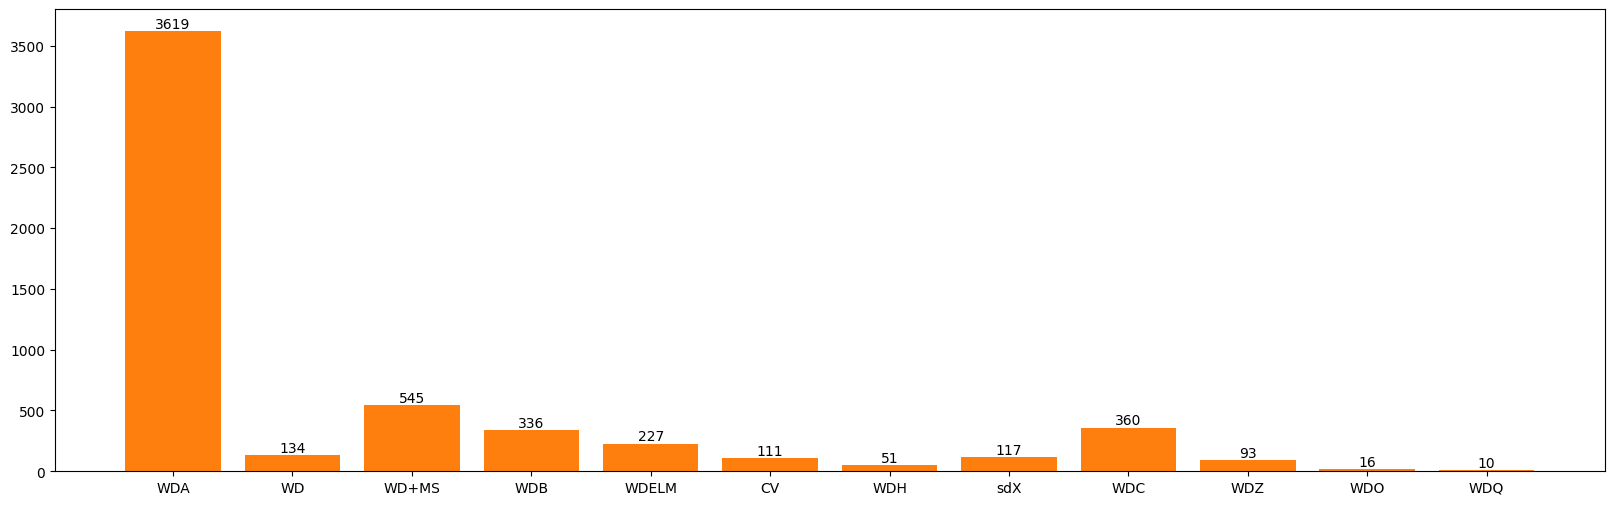

In [27]:
counter = Counter(spectrum_df['classID'])
star_class = counter.keys()
star_counts = counter.values()

# Plot bar graph of star classes using matplotlib

indexes = np.arange(len(star_class))
width = 0.7
fig, ax = plt.subplots(figsize=(20,6))
plt.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)
plt.xticks(indexes , star_class)
plt.show()

Now that we have the spectrum data (represented en each .dat filename) and label data in a single dataframe, we will split this into 3 data sets: training, validation and test sets. 

## Training, test and validation sets.

First, we will divide our available data into training, test and validation sets, for the upcoming ML algorithms,

In [28]:
# just for checking all data files have the same flux and wavelenght length, 4648. They do, but this code is slow.

# for index, filename in spectrum_df['filename'].iteritems():
#     sed = np.loadtxt(os.path.join(sdss_data_path, filename), unpack = True)
#     wavelength = sed[0,:]
#     flux = sed[1,:]
#     ivar = sed[2,:]
#     if len(flux) + len(wavelength) != (4648 + 4648):
#         print(index, filename, len(flux), len(wavelength))

In [29]:
# We will use the stratified shuffle function from scikit learn becauses of our
# imbalanced data setm and so all of our sets will contain samples from all classes proportionally. 

from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.4, random_state=42)
for train_index, test_index in split.split(spectrum_df, spectrum_df["classID"]):
    train_set = spectrum_df.loc[train_index]
    test_valid_set = spectrum_df.loc[test_index]


split2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
for test_index, valid_index in split2.split(test_valid_set, test_valid_set["classID"]):
    test_set = test_valid_set.iloc[test_index]
    valid_set = test_valid_set.iloc[valid_index]

In [30]:
print(spectrum_df.shape, train_set.shape, test_set.shape, valid_set.shape)

(5619, 2) (3371, 2) (1124, 2) (1124, 2)


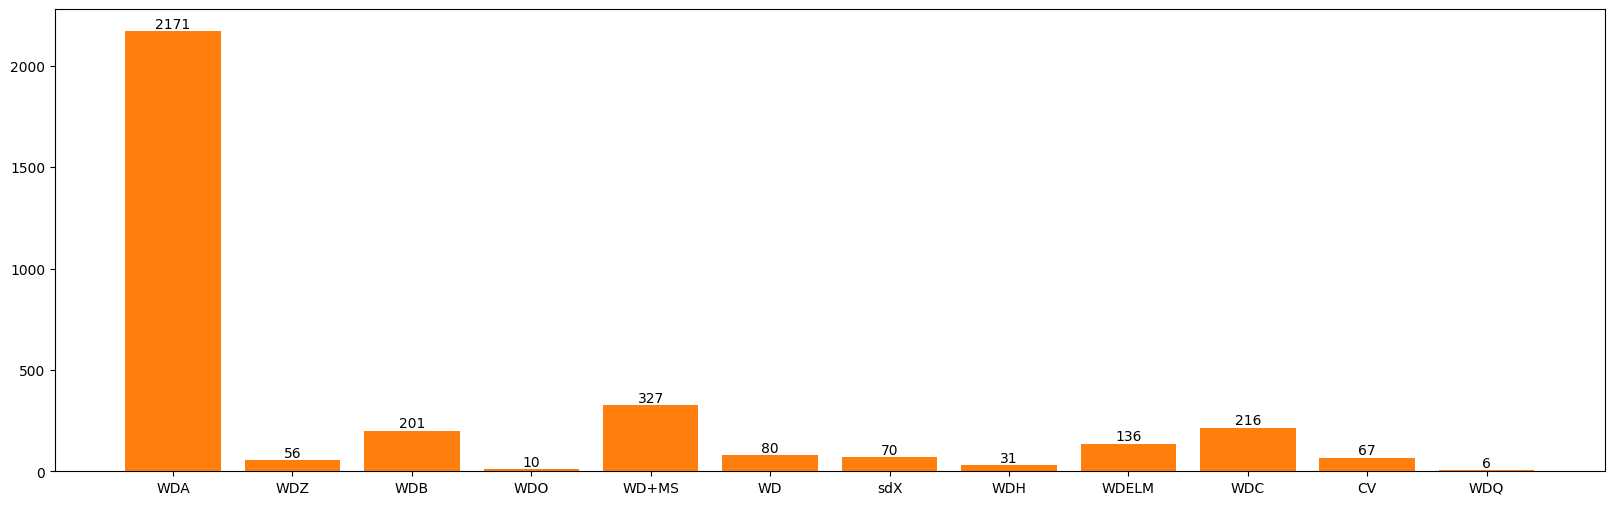

In [31]:
counter = Counter(train_set['classID'])
star_class = counter.keys()
star_counts = counter.values()

# Plot bar graph of star classes using matplotlib

indexes = np.arange(len(star_class))
width = 0.7
fig, ax = plt.subplots(figsize=(20,6))
plt.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)
plt.xticks(indexes , star_class)
plt.show()

We also use one hot encoding for the labels of each file, so we will build a dictionary with the code for each class.

In [32]:
# Hot encoding dictionary
counter = Counter(train_set['classID'])
star_class = counter.keys()

stars_encoding = dict()
star_class = list(star_class)
num_classes = len(star_class)


for label in star_class:
    code = np.zeros(num_classes)
    code[star_class.index(label)] = 1
    stars_encoding[label] = code
print(stars_encoding, len(stars_encoding))

{'WDA': array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'WDZ': array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'WDB': array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'WDO': array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]), 'WD+MS': array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]), 'WD': array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]), 'sdX': array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]), 'WDH': array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]), 'WDELM': array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]), 'WDC': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]), 'CV': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]), 'WDQ': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])} 12


We want to load a numpy array (or matrix) for each set we are one use, normalizing around a central frequency. We will also discard the tails of the data (where there is usually high noise and no feature should be important). Playing around with a particular wavelenght, I decided to cut the data to wavelength[48:-400] (3605 - 9477 [A] app) and normalize the data around the element 2100 (5847 [A] app). The resulting lenght of the arrays is 4200.

The following function will do the work of building numpy arrays from each dataframe.

In [38]:
# We want to load a matrix from the training data, given the data size this wil be acceptable.
import statistics

def data_processing_and_loading(sdss_data_path, block_df, stars_encoding):
    """
    The following function takes a dataframe consisting of two columns: filename of .dat
    file and class ID, and returns numpy arrays consisting of the spectrum data matrix
    and one hot encoded label matrix.

    This functions also does some flux data pre-processing, trimming the edges of the signal 
    and normalizing flux magnitud to 1 around 5847 [A] 

    :sdss_data_path: path to folders where each subfolder contains .dat files.
    :block_df: dataframe with two columns, filenames and class id.
    :stars_enconding: dictionary with one hot encoding. 
    :return: returns two numpy arrays, one for the spectrum data and one for the one hot encoded label data, 
    and the filename of spectrums with nan data which will be removed from the datasets.
    """ 
    to_remove = list()
    num_of_classes = len(stars_encoding)
    spectrum_matrix = np.empty((0,4200), float)
    label_enc_matrix = np.empty((0, num_of_classes), float)

    for _, row in block_df.iterrows():
        file_path = os.path.join(sdss_data_path, row['filename'])
        sed = np.loadtxt(file_path, unpack = True)
        wavelength = sed[0,48:-400]
        flux = sed[1,48:-400]
        norm_magnitude = statistics.mean(flux[2050:2100])
        flux = np.divide(flux, flux[2100])
        if(np.isnan(flux).any() or np.isnan(wavelength).any()):
            print('Nan data found for file {}'.format(file_path))
            to_remove.append(row['filename'])
        else:
            #flux = flux[:3750]  # Recorta a 3750 puntos
            #spectrum_matrix = np.append(spectrum_matrix, np.transpose(flux[:, None]), axis=0)
            spectrum_matrix = np.append(spectrum_matrix, np.transpose(flux[:, None]), axis=0)
            label_enc_matrix = np.append(label_enc_matrix, np.transpose(stars_encoding[row['classID']][:, None]), axis=0)
    return spectrum_matrix, label_enc_matrix, to_remove

We will run the above function for the training, test and validation sets, and save the six matrices, two from each set. We will also save the three dataframes corresponding to each set, after we have removed the elements that have NaN flux values, whose filename is returned in the to_remove list of the above function. 


### Validation Set Pre-processing:

In [39]:
from numpy import save

validation_spectrum_matrix, validation_label_matrix, valid_to_remove = data_processing_and_loading(sdss_data_path, valid_set, stars_encoding)

# save numpy matrices

save(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\validation_spectrum_matrix.npy'), validation_spectrum_matrix)
save(os.path.join(project_dir,r'notebooks\1.0-jrb-alternative-approach\validation_label_matrix.npy'), validation_label_matrix)

# remove validation set elements with nan flux values from dataframe
print(valid_set.shape)
for element in valid_to_remove:
    valid_set.drop(valid_set.index[valid_set['filename'] == element], inplace = True)
print(valid_set.shape)


# save validation set dataframe as csv file.
valid_set.to_csv(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\valid_set.csv'), index=False)

# code to see size of each numpy array
# print(train_matrix.nbytes, train_matrix.shape)
# print(train_label_matrix.nbytes, train_label_matrix.shape)

(1123, 2)
(1123, 2)


### Test Set Pre-Processing

In [40]:
test_spectrum_matrix, test_label_matrix, test_to_remove = data_processing_and_loading(sdss_data_path, test_set, stars_encoding)

# save numpy matrices

save(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\test_spectrum_matrix.npy'), test_spectrum_matrix)
save(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\test_label_matrix.npy'), test_label_matrix)

# remove test set elements with nan flux values from dataframe
print(test_set.shape)
for element in test_to_remove:
    test_set.drop(test_set.index[test_set['filename'] == element], inplace = True)
print(test_set.shape)


# save test set dataframe as csv file.
test_set.to_csv(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\test_set.csv'), index=False)

(1124, 2)
(1124, 2)


### Trainig set Pre-Processing

In [41]:
train_spectrum_matrix, train_label_matrix, train_to_remove = data_processing_and_loading(sdss_data_path, train_set, stars_encoding)

# save numpy matrices

save(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\training_spectrum_matrix.npy'), train_spectrum_matrix)
save(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\training_label_matrix.npy'), train_label_matrix)

# remove training set elements with nan flux values from dataframe
print(train_set.shape)
for element in train_to_remove:
    train_set.drop(train_set.index[train_set['filename'] == element], inplace = True)
print(train_set.shape)


# save training set dataframe as csv file.
train_set.to_csv(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\train_set.csv'), index=False)

C:\Users\javip\AppData\Local\Temp\ipykernel_13888\2631107380.py:30: RuntimeWarning: invalid value encountered in divide
  flux = np.divide(flux, flux[2100])


Nan data found for file C:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\data\raw\sdss_dat_files\wd\SDSSJ064150.28+010218.9_15281-59273-0172_4523766551.dat
Nan data found for file C:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\data\raw\sdss_dat_files\wd\SDSSJ073701.27+155642.2_15073-59186-0161_4542151181.dat
Nan data found for file C:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\data\raw\sdss_dat_files\wd\SDSSJ052341.99-021132.3_15075-59216-0422_4417173069.dat
Nan data found for file C:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\data\raw\sdss_dat_files\cb_gaiagalex\SDSSJ053843.63+394006.8_15225-59272-0322_4519646512.dat
Nan data found for file C:\Users\javip\OneDrive - Universidad Técnica Federico Santa María\6to año\elo308\ML_NPF\data\raw\sdss_dat_files\wd\SDSSJ054226.67+204651.2_15226-59265-0033_4504259165.dat
(3371, 2)


Now we have loaded and saved all data (the spectrums data after pre-processing and the label data) as numpy arrays. The size of the matrices is small enough for a personal computer in most cases. Now, we'll proceed doing a grid search over different parameters
 of an artificial neural network (ANN) using keras.

### A note on K-Fold Cross validation

For this first approach, we will not be implementing K-Fold cross validation for splitting the training set into smaller training and validations set in an iterative way. This is very useful, but is time consuming and requires more data from the under represented classes (a problem we will takle using some Data Augmentation strategy), and so is not suited for this simple demonstration. One important note is that, when K-Fold Cross validation is implemented, we should modify the default python funtions we'll use (most liekly from scikit-learn) so as to consider the fact that we are wroking on an imbalanced set.

In [36]:
stars_encoding

{'WDA': array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'WDZ': array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'WDB': array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'WDO': array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'WD+MS': array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]),
 'WD': array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]),
 'sdX': array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]),
 'WDH': array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
 'WDELM': array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]),
 'WDC': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]),
 'CV': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]),
 'WDQ': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])}